1/路線圖跟倉庫匯入

In [2]:
!pip -q install openpyxl pandas numpy matplotlib


from google.colab import files
uploaded = files.upload()
uploaded = files.upload()

Saving 倉庫(1).xlsx to 倉庫(1).xlsx


Saving routes_for_flexsim.csv to routes_for_flexsim (1).csv


2/讀檔 路線跟倉庫

In [3]:
import pandas as pd
from pathlib import Path

wh_xlsx = "倉庫(1).xlsx"
routes_csv = "routes_for_flexsim.csv"

# 1) 倉庫地圖（Excel）
xl = pd.ExcelFile(wh_xlsx)
print("工作表：", xl.sheet_names)
grid = xl.parse(xl.sheet_names[0])  # 取第一個工作表
print("倉庫格網大小:", grid.shape)
display(grid.head())

# 2) 路線（CSV）
routes = pd.read_csv(routes_csv, encoding="utf-8")
print("路線資料筆數:", routes.shape)
print("欄位:", list(routes.columns))
display(routes.head(10))


工作表： ['工作表1']
倉庫格網大小: (60, 31)


,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
0,0,1,1,0,2,2,0,3,3,0,...,0,8,8,0,9,9,0,10,10,0
1,0,1,1,0,2,2,0,3,3,0,...,0,8,8,0,9,9,0,10,10,0
2,0,1,1,0,2,2,0,3,3,0,...,0,8,8,0,9,9,0,10,10,0
3,0,1,1,0,2,2,0,3,3,0,...,0,8,8,0,9,9,0,10,10,0
4,0,1,1,0,2,2,0,3,3,0,...,0,8,8,0,9,9,0,10,10,0


路線資料筆數: (374, 6)
欄位: ['AGV_ID', 'Order', 'Step', 'X', 'Y', 'Action']


,AGV_ID,Order,Step,X,Y,Action
0,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",1.0,15,0,MOVE
1,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",2.0,16,0,MOVE
2,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",3.0,17,0,MOVE
3,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",4.0,18,0,MOVE
4,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",5.0,19,0,MOVE
5,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",6.0,20,0,MOVE
6,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",7.0,21,0,MOVE
7,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",8.0,22,0,MOVE
8,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",9.0,23,0,MOVE
9,AGV-1,"Task-1,Task-2,Task-3,Task-4,Task-5",10.0,24,0,MOVE


3/疊圖

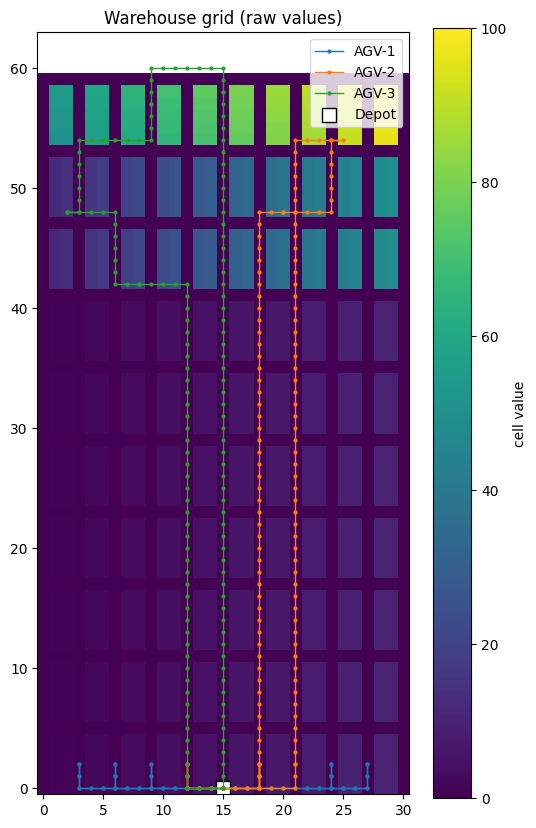

In [4]:
import numpy as np
import matplotlib.pyplot as plt

CELL_M = 1.0            # 一格一公尺
DEPOT_XY = (15, 0)      # 你提供的 depot

# 倉庫圖可視化（0 = 走道；其他數字可能是貨架/貨位 ID）
plt.figure(figsize=(6,10))
plt.imshow(grid.values, origin='upper', interpolation='nearest')
plt.title("Warehouse grid (raw values)")
plt.colorbar(label='cell value')

# 疊三台 AGV 的路線
for agv_id, g in routes.groupby("AGV_ID"):
    xy = g.sort_values("Step")[["X","Y"]].to_numpy()
    plt.plot(xy[:,0], xy[:,1], marker='o', linewidth=1, markersize=2, label=agv_id)

# depot 標記
plt.scatter([DEPOT_XY[0]], [DEPOT_XY[1]], s=100, marker='s', edgecolor='k', facecolor='white', label='Depot')
plt.legend()
plt.gca().invert_yaxis()  # 因為 grid origin='upper'
plt.show()


4/能耗相關參數與權重輸入

In [6]:
import math

PARAMS = {
    "v": 1.39,                 # m/s ≈ 5 km/h
    "m_vehicle": 110.0,        # kg
    "m_item": 10.0,            # kg/件
    "mu": 0.02,                # 滾動阻力係數
    "g": 9.81,                 # m/s^2
    "M_turn": 10.0,            # J/rad
    "theta_per_turn": math.pi/2,  # 90°
    "lift_h": 0.5,             # m
    "lift_eta": 0.7,           # 效率
    "P_idle": 100.0,           # W
    "T_idle_per_pick": 2.0,    # s/件
}



5/計算能耗

In [13]:
import numpy as np
import pandas as pd

def compute_agv_energy(df: pd.DataFrame, params: dict, cell_m: float = 1.0) -> dict:
    v = params["v"]; m0 = params["m_vehicle"]; m1 = params["m_item"]
    mu = params["mu"]; g = params["g"]
    M_turn = params["M_turn"]; theta = params["theta_per_turn"]
    h = params["lift_h"]; eta = params["lift_eta"]
    P_idle = params["P_idle"]; T_idle = params["T_idle_per_pick"]

    df = df.sort_values("Step").copy()
    xy = df[["X","Y"]].to_numpy(dtype=float)
    pickup_mask = df["Action"].fillna("MOVE").str.startswith("PICKUP_").to_numpy()
    pickups_cum = np.cumsum(pickup_mask).astype(int)

    dxy = np.diff(xy, axis=0)
    manh = np.abs(dxy).sum(axis=1)
    move_mask = manh > 0
    dir_vecs = np.sign(dxy[move_mask])

    turns = sum(1 for i in range(1, len(dir_vecs)) if not np.array_equal(dir_vecs[i], dir_vecs[i-1]))
    Ct_m = float((manh[move_mask] * cell_m).sum())

    m_total_edges = (m0 + m1 * pickups_cum[:-1])[move_mask]
    d_m_edges = manh[move_mask] * cell_m

    E_roll = float((mu * m_total_edges * g * d_m_edges).sum())
    E_accel_perEdge = float((0.5 * m_total_edges * (v**2)).sum())

    accel_events = 0
    if len(dir_vecs) > 0:
        accel_events = 1 + sum(1 for i in range(1, len(dir_vecs)) if not np.array_equal(dir_vecs[i], dir_vecs[i-1]))
    avg_mass = float(m_total_edges.mean()) if len(m_total_edges) else m0
    E_accel_turnOnly = float(0.5 * avg_mass * (v**2) * accel_events)

    E_rot  = float(turns * (M_turn * theta))
    n_picks = int(pickup_mask.sum())
    E_lift = float(n_picks * (m1 * g * h / eta))
    E_idle = float(P_idle * T_idle * n_picks)

    return {
        "Ct_m": Ct_m,
        "turns": int(turns),
        "n_picks": n_picks,
        "E_roll_J": E_roll,
        "E_accel_perEdge_J": E_accel_perEdge,
        "E_accel_turnOnly_J": E_accel_turnOnly,
        "E_rot_J": E_rot,
        "E_lift_J": E_lift,
        "E_idle_J": E_idle,
        "E_total_perEdge_J": E_roll + E_accel_perEdge + E_rot + E_lift + E_idle,
        "E_total_turnOnly_J": E_roll + E_accel_turnOnly + E_rot + E_lift + E_idle,
    }


6/權重跟上下限（後面計算是用上限，最大的意思）


In [17]:
rows = []
for agv_id, g in routes.groupby("AGV_ID"):
    stats = compute_agv_energy(g, PARAMS, cell_m=CELL_M)
    rows.append({"AGV_ID": agv_id, **stats})

per_agv = pd.DataFrame(rows).sort_values("AGV_ID")
totals = {"AGV_ID": "ALL", **{c: per_agv[c].sum() for c in per_agv.columns if c != "AGV_ID"}}
out_df = pd.concat([per_agv, pd.DataFrame([totals])], ignore_index=True)

GAMMA = 0.5   # Score 權重
DELTA = 0.5


# ✅ 在這裡統一用唯一的 GAMMA/DELTA 計分
out_df["Score_perEdge"]  = GAMMA * out_df["E_total_perEdge_J"]  + DELTA * out_df["Ct_m"]
out_df["Score_turnOnly"] = GAMMA * out_df["E_total_turnOnly_J"] + DELTA * out_df["Ct_m"]
display(out_df.round(3))


,AGV_ID,Ct_m,turns,n_picks,E_roll_J,E_accel_perEdge_J,E_accel_turnOnly_J,E_rot_J,E_lift_J,E_idle_J,E_total_perEdge_J,E_total_turnOnly_J,Score_perEdge,Score_turnOnly
0,AGV-1,68.0,15,5,1789.344,8810.376,2073.030,235.619,350.357,1000.0,12185.697,5448.350,6126.848,2758.175
1,AGV-2,142.0,13,5,4047.606,19929.611,1964.891,204.204,350.357,1000.0,25531.778,7567.058,12836.889,3854.529
2,AGV-3,146.0,10,5,4041.720,19900.630,1499.363,157.080,350.357,1000.0,25449.787,7048.519,12797.893,3597.260
3,ALL,356.0,38,15,9878.670,48640.617,5537.283,596.903,1051.071,3000.0,63167.262,20063.927,31761.631,10209.964


7/ 看一下能耗怎麼分佈

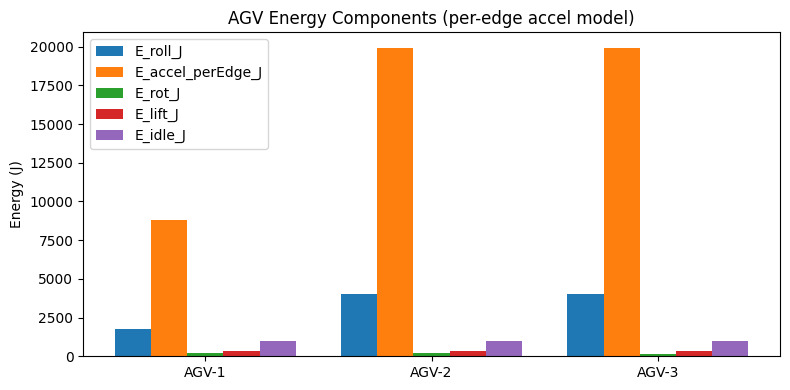

In [18]:
import numpy as np
import matplotlib.pyplot as plt

bars = ["E_roll_J", "E_accel_perEdge_J", "E_rot_J", "E_lift_J", "E_idle_J"]
labels = per_agv["AGV_ID"].tolist()
x = np.arange(len(labels))
width = 0.16

plt.figure(figsize=(8,4))
for i, b in enumerate(bars):
    plt.bar(x + (i-2)*width, per_agv[b].values, width, label=b)

plt.xticks(x, labels)
plt.ylabel("Energy (J)")
plt.title("AGV Energy Components (per-edge accel model)")
plt.legend()
plt.tight_layout()
plt.show()


8/ score

In [19]:
import pandas as pd
import numpy as np

# ---------- 選擇加速模型 ----------
# 'per_edge'   = 每段移動都視為一次加速（較保守、上限）
# 'turn_only'  = 只有起步與轉彎才視為加速（較樂觀、下限）
ACCEL_MODEL = 'per_edge'   # 需要可改成 'turn_only'

def build_solution_and_data_for_ev(df: pd.DataFrame, cell_m: float = 1.0, depot_xy=(15,0), params: dict = None):
    """把 CSV 的 (X,Y) 座標序列轉成 local nodes 與 path，生成 solution/data 給 ev 使用。"""
    params = params or {}

    # 依 AGV 合成 path（每台 AGV 視為 1 趟；若要按 Order 拆趟可在這裡改）
    solution = {}
    all_nodes = []
    for agv_id, sdf in df.groupby("AGV_ID"):
        sdf = sdf.sort_values("Step")
        coords = list(map(tuple, sdf[["X","Y"]].to_numpy(dtype=int)))
        all_nodes.extend(coords)

    # 建立 local index
    unique_nodes = list(dict.fromkeys(all_nodes))  # 保序去重
    node_to_idx = {xy:i for i,xy in enumerate(unique_nodes)}

    # 每台 AGV 路徑 → index path
    for agv_id, sdf in df.groupby("AGV_ID"):
        sdf = sdf.sort_values("Step")
        coords = list(map(tuple, sdf[["X","Y"]].to_numpy(dtype=int)))
        idx_path = [node_to_idx[xy] for xy in coords]
        solution.setdefault(agv_id, []).append({"path": idx_path})

    # 全配對距離（格）
    N = len(unique_nodes)
    D = np.zeros((N, N), dtype=float)
    for i,(x1,y1) in enumerate(unique_nodes):
        for j,(x2,y2) in enumerate(unique_nodes):
            D[i,j] = abs(x1-x2) + abs(y1-y2)

    if depot_xy not in node_to_idx:
        raise ValueError(f"depot {depot_xy} 不在路線座標中，請確認 CSV 是否包含起訖 depot")

    data = {
        "distance_small": D,
        "depot_small": node_to_idx[depot_xy],
        "cell_m": cell_m,
        # 能耗參數（若你的 ev 會用到）
        **PARAMS
    }
    data["nodes_xy"] = np.array(unique_nodes, dtype=int)
    return solution, data

# 介面相容版（若你沒有原本的 WarehouseEvaluatorLite，就會用這個）
class WarehouseEvaluatorLite_Compat:
    def __init__(self, gamma=0.5, delta=0.5):
        self.gamma = float(gamma)
        self.delta = float(delta)
    def objective(self, E_total: float, Ct: float) -> float:
        return self.gamma * float(E_total) + self.delta * float(Ct)
    def penalty(self, solution, data) -> float:
        return 0.0
    def compute_E_and_Ct(self, solution, data):
        D = data["distance_small"]
        cell_m = float(data.get("cell_m", 1.0))
        dist_cells = 0.0
        for k, trips in solution.items():
            for trip in trips:
                path = trip["path"]
                for a,b in zip(path, path[1:]):
                    dist_cells += float(D[a,b])
        Ct = dist_cells * cell_m
        # E_total 交由外部已算好的數值帶入（這裡回 0 以便外面覆蓋）
        return 0.0, Ct
    def score(self, solution, data, E_total, Ct):
        return self.objective(E_total, Ct)

# ---- 建立整體 solution/data + ev（只引用第4步的 GAMMA/DELTA）----
solution, data_ev = build_solution_and_data_for_ev(routes, cell_m=CELL_M, depot_xy=DEPOT_XY, params=PARAMS)
try:
    ev = WarehouseEvaluatorLite(gamma=GAMMA, delta=DELTA)  # 如果你已貼上自己的類別
except NameError:
    ev = WarehouseEvaluatorLite_Compat(gamma=GAMMA, delta=DELTA)

# ---- 計算全案 E_total（依選擇的加速模型），Ct 用 ev 算 ----
def _energy_total_overall(routes_df: pd.DataFrame) -> float:
    e_sum = 0.0
    for _, g in routes_df.groupby("AGV_ID"):
        stats = compute_agv_energy(g, PARAMS, cell_m=CELL_M)
        e_sum += stats["E_total_perEdge_J"] if ACCEL_MODEL == 'per_edge' else stats["E_total_turnOnly_J"]
    return float(e_sum)

E_total_all = _energy_total_overall(routes)
_, Ct_all = ev.compute_E_and_Ct(solution, data_ev)

score_all = ev.score(solution, data_ev, E_total_all, Ct_all)
pen_all = ev.penalty(solution, data_ev)

print(f"Ct(距離): {Ct_all:.2f}")
print(f"E_total(能耗J): {E_total_all:.2f}")
print(f"Score(γE+δCt): {score_all:.2f}")
print("Penalty total:", pen_all)

# ---- 各車明細（Ct/E_total/Score/Penalty）----
rows = []
for agv_id, g in routes.groupby("AGV_ID"):
    stats = compute_agv_energy(g, PARAMS, cell_m=CELL_M)
    E_agv = stats["E_total_perEdge_J"] if ACCEL_MODEL == 'per_edge' else stats["E_total_turnOnly_J"]

    # 該車的 Ct 用 ev 算（確保 Ct 與整體定義一致）
    sol_agv, data_agv = build_solution_and_data_for_ev(g, cell_m=CELL_M, depot_xy=DEPOT_XY, params=PARAMS)
    _, Ct_agv = ev.compute_E_and_Ct(sol_agv, data_agv)

    score_agv = ev.score(sol_agv, data_agv, E_agv, Ct_agv)
    pen_agv = ev.penalty(sol_agv, data_agv)

    rows.append({"AGV_ID": agv_id, "Ct_m": Ct_agv, "E_total_J": E_agv, "Score": score_agv, "Penalty": pen_agv})

per_agv_scores = pd.DataFrame(rows).sort_values("AGV_ID").reset_index(drop=True)

# 檢核 + 總表列
sum_row = {
    "AGV_ID": "ALL",
    "Ct_m": per_agv_scores["Ct_m"].sum(),
    "E_total_J": per_agv_scores["E_total_J"].sum(),
    "Score": per_agv_scores["Score"].sum(),
    "Penalty": per_agv_scores["Penalty"].sum(),
}
per_agv_scores = pd.concat([per_agv_scores, pd.DataFrame([sum_row])], ignore_index=True)

# 一致性檢查（Penalty=0 且線性目標時，總分等於各車分數相加）
assert abs(score_all - per_agv_scores.loc[per_agv_scores["AGV_ID"] != "ALL","Score"].sum()) < 1e-6, \
       "全案 Score 與各車 Score 加總不一致，請檢查權重或路徑拆分。"

display(per_agv_scores.round(3))

# （可選）存成 CSV 方便留檔
# per_agv_scores.to_csv("per_agv_scores.csv", index=False, encoding="utf-8")
# from google.colab import files; files.download("per_agv_scores.csv")


Ct(距離): 356.00
E_total(能耗J): 63167.26
Score(γE+δCt): 31761.63
Penalty total: 0.0


,AGV_ID,Ct_m,E_total_J,Score,Penalty
0,AGV-1,68.0,12185.697,6126.848,0.0
1,AGV-2,142.0,25531.778,12836.889,0.0
2,AGV-3,146.0,25449.787,12797.893,0.0
3,ALL,356.0,63167.262,31761.631,0.0


9/匯入新的路線圖時